# Building an In Silico Brain: Breaking the Compute Bottleneck
**Encode Fellowship Demo | Laura Porta**

Building an "in silico brain" requires the ability to map neural activity back to environmental stimuli accurately and at scale. However, reproducing modern neural movie decoders (like the input optimization approach from Bauer et al. 2026) comes with a severe engineering tradeoff, restricting deployment to high-end compute clusters.

In this demo, I will show how I transitioned a highly expensive computational model into a modular, production-ready decoder capable of running on standard hardware.


In [1]:
from neurodecoders.demo import (
    setup_environment, get_validation_dataset_path,
    load_demo_data, select_best_runs,
    load_models, reconstruct_samples, save_reconstruction_gifs,
    plot_validation_environment, plot_firing_rates, plot_inference_time, plot_reconstructions,
)

setup_environment()

### 1. The Validation Space: Synthetic Neural Responses
To systematically test architectures, I built a modular synthetic validation environment using CIFAR10 and Gabor filter receptive fields. This acts as our "toy space" to evaluate model fidelity before committing to costly in-vivo datasets.


/nfs/nhome/live/lporta/source/neurodecoders/neurodecoders/demo.py:310: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


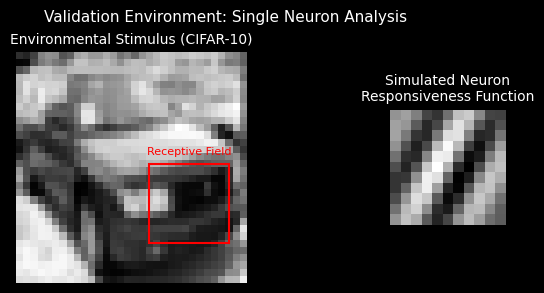

In [2]:
dataset_path = get_validation_dataset_path()
plot_validation_environment(dataset_path)

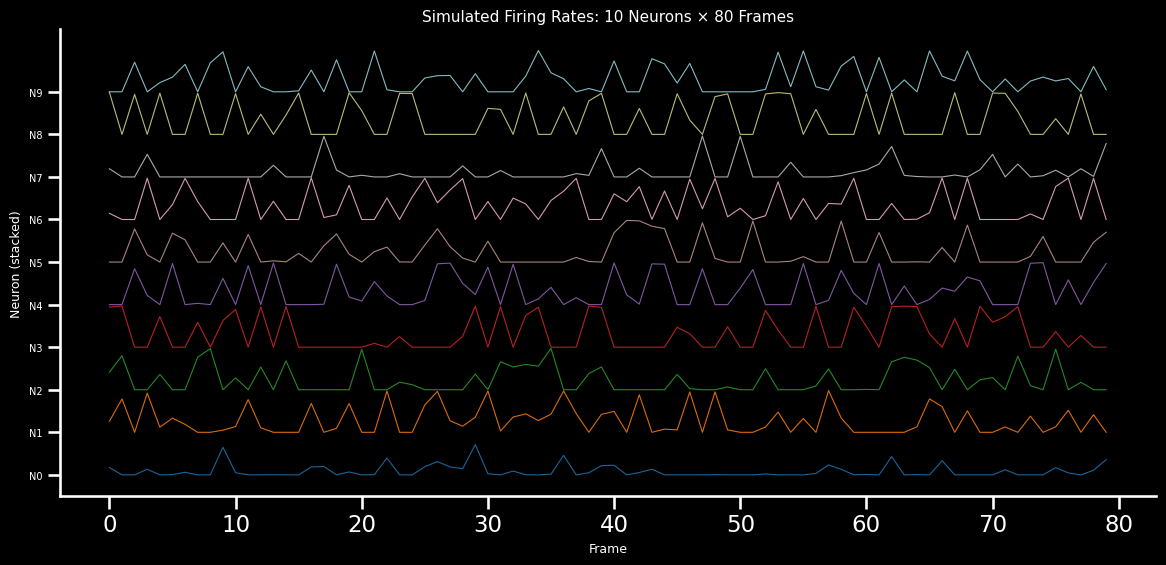

In [3]:
plot_firing_rates(dataset_path)

### 2. The Bottleneck: Input Optimization
The original approach attempts to recover the stimulus by iteratively optimizing an input mapping directly against a Poisson mean loss. It functions, but the loop is intensely heavy.

```python
# The highly expensive "Input Optimization" bottleneck loop
for step in range(input_optim_steps): # Usually 1,000 steps per frame!
    optimizer.zero_grad()
    predicted_firing_rates = encoder(optimized_input)
    loss = poisson_mean_loss(predicted_firing_rates, actual_rates)
    loss.backward()
    optimizer.step()
```

### 3. The Optimization: From Loops to Guided Decoders Component APIs
To eliminate the iterative optimization, I completely refactored the pipeline. I swapped heavy optimization loops for a feed-forward Guided Decoder and deterministic diffusion (DDIM) steps, modularizing the structure into a clean API.

```python
# The refactored clean API: single-pass or lightweight DDIM loops
predicted_stimulus = guided_decoder(neural_responses)
# -- or --
predicted_stimulus = diffusion_sampler(neural_responses, steps=50) # Down from 1000!
```

Let's select the best-performing run for each architecture from our experiment database:

In [4]:
selected = select_best_runs()

2026/03/24 20:17:29 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/03/24 20:17:29 INFO mlflow.store.db.utils: Updating database tables
INFO  [alembic.runtime.migration] Context impl PostgresqlImpl.
INFO  [alembic.runtime.migration] Will assume transactional DDL.
INFO  [alembic.runtime.migration] Context impl PostgresqlImpl.
INFO  [alembic.runtime.migration] Will assume transactional DDL.


### 4. The Payoff: Side-By-Side Comparison
We compare all four approaches using neuronal consistency (how well the decoder preserves neural similarity) and inference time.

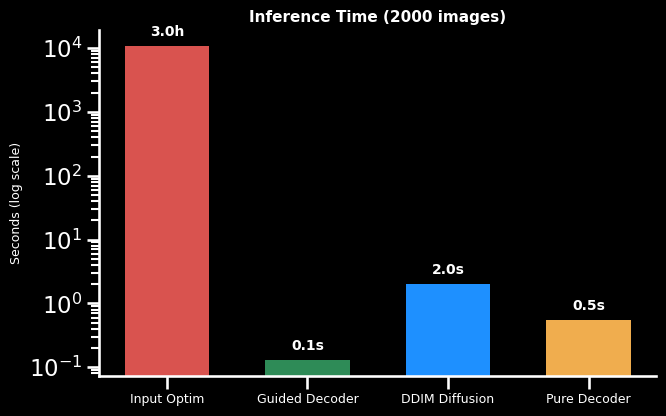

In [5]:
plot_inference_time(selected)

### Reconstructed Examples
Let's visually compare what the reconstructed stimuli look like. We use the same models selected above to generate live reconstructions on held-out test images.

In [6]:
test_images, test_firing = load_demo_data()
models, encoder = load_models(selected)

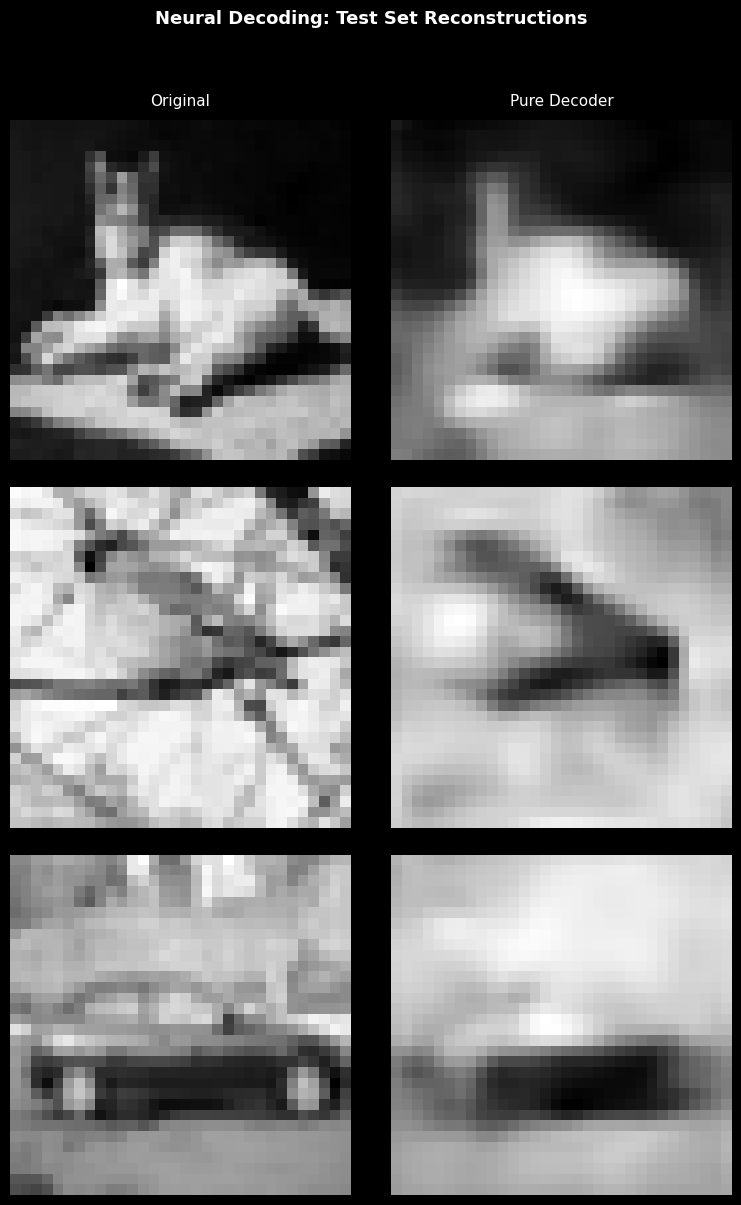

In [7]:
sample_indices = [42, 12, 156]
results, originals = reconstruct_samples(
    models, encoder, test_firing, test_images, sample_indices
)
plot_reconstructions(originals, results, sample_indices)

In [8]:
save_reconstruction_gifs(models, encoder, test_firing, test_images, n_images=10);